In [15]:
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

load_dotenv()

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

# **Tools**

In [16]:
# Tool -1 duck duck go search
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun(description="this tool is to search the web for news")

# search_tool.invoke("Obama's first name?")

# Tool -2 wikipedia search tool

from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper


wikipedia_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(),description="this tool is to search Wikipedia")


# Tool -3 [custom Enterprise Tool]
from langchain.tools import tool

@tool
def enterprise_tool(query:str)->str:
    """this is tool to send email to employees"""

    return "Email sent"

In [17]:
Toolkit=[search_tool,wikipedia_tool,enterprise_tool]
Toolkit

[DuckDuckGoSearchRun(description='this tool is to search the web for news', api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text')),
 WikipediaQueryRun(description='this tool is to search Wikipedia', api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\asus\\Desktop\\langchain-project\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000)),
 StructuredTool(name='enterprise_tool', description='this is tool to send email to employees', args_schema=<class 'langchain_core.utils.pydantic.enterprise_tool'>, func=<function enterprise_tool at 0x000001BEA6399DA0>)]

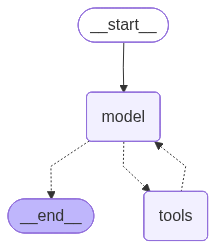

In [ ]:
from langchain.agents import create_agent
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()

model = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.1,
    max_tokens=1000,
    timeout=30
)

agent = create_agent(model, tools=Toolkit)
agent

## **ReAct Agent invoke with Stream**

In [26]:
example_query = "give me the lastest news about war"

events = agent.stream(
    {"messages": [("user", example_query)]},
    stream_mode="values",
     config={"recursion_limit": 15}
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

give me the lastest news about war
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (xxnkyc5vh)
 Call ID: xxnkyc5vh
  Args:
    query: latest news about war
================================= Tool Message =================================
Name: duckduckgo_search

These were the updates on the US-Israeli war on Iran on Tuesday, April 14, 2026. Iran, US, Israel War News Live Updates: 'I am permanently opening Strait of Hormuz', says Trump Iran, US, Israel War Today News Live Updates: Donald Trump's letter to Xi Jinping comes even as Iran said if the US continues its blockade its armed forces would not allow "any exports or imports to continue in the Persian Gulf, the Sea of Oman, and the Red Sea". Iran US Israel War Live Updates: After a protracted 21-hour negotiation, the US and Iran were unable to come to a peace agreement. "The bad news is th

GraphRecursionError: Recursion limit of 15 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT

## **manually binding the llm tools**

In [ ]:
#without binding
llm.invoke("what is the latest news about stock-market")

AIMessage(content="As my knowledge cutoff is December 2023, I'll provide you with a general overview of the stock market trends and news up to that point. Please note that the information may not be up-to-date, and I recommend checking with a reliable news source for the latest developments.\n\n**Global Market Trends (as of December 2023):**\n\n1. **Interest Rate Hikes:** The US Federal Reserve, European Central Bank, and other central banks continued to raise interest rates to combat inflation, which had a mixed impact on the stock market.\n2. **Inflation Concerns:** Inflation remained a significant concern, with many countries experiencing high inflation rates, which affected consumer spending and business profitability.\n3. **Economic Slowdown:** The global economy showed signs of slowing down, with many countries experiencing a decline in GDP growth, which had a negative impact on the stock market.\n4. **Geopolitical Tensions:** Ongoing geopolitical tensions, such as the Russia-Ukr

In [ ]:
#with binding
llm_binded=llm.bind_tools(Toolkit)
llm_binded.invoke("what is the latest news about stock market?")





AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'wkvbtm1re', 'function': {'arguments': '{"query":"latest stock market news"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 354, 'total_tokens': 374, 'completion_time': 0.047257058, 'completion_tokens_details': None, 'prompt_time': 0.053978856, 'prompt_tokens_details': None, 'queue_time': 0.160138124, 'total_time': 0.101235914}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d915a-9a3e-7d60-81ab-a5e59839dc8c-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'latest stock market news'}, 'id': 'wkvbtm1re', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 354, 'output_tokens': 20, 'total_tokens': 374})

: 